In [104]:
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import numpy as np
import funzioni as f
importlib.reload(f)

import matplotlib.pyplot as plt
import grafici as gf
importlib.reload(gf)

<module 'grafici' from '/home/nichettg/Linux Programmi/Codici/grafici.py'>

# 1. Raccolta dati

Funzione conversione unità di misura

In [105]:
def converti(P_kgcm2, V_cm3, T_C):
    
    # 1 kg/cm² = 98_066.5 Pa
    P_Pa = 98066.5 * P_kgcm2
    # 1 cm³ = 1e6 m³
    V_m3 = 1e-6 * V_cm3
    # °C to K
    T_K = T_C + 273.15

    return P_Pa, V_m3, T_K

Lettura dati cartella Data

In [106]:
import os

input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati = []

for input_file in input_files:

    array = np.loadtxt(input_file)
    P = array[:, 0]  # prima colonna: pressione
    V = array[:, 1]  # seconda colonna: volume
    T = array[:, 2]  # terza colonna: temperatura
    #dati.append(converti(P, V, T))
    dati.append((P, V, T))

sx = 0.01 / np.sqrt(12)
#sy = 0.001 / np.sqrt(12)
sy = 0.3

Tabelle di controllo

In [107]:
from tabulate import tabulate

titoli, tabelle = [], []

for i, (P, V, T) in enumerate(dati):
    titolo = f"<h4>Temperatura {i+1}5 °C</h4>"
    rows = list(zip(P, V, T))
    headers = ["P [kg/cm²]", "V [cm³]", "T [°C]"]
    tabella_html = tabulate(rows, headers=headers, floatfmt=(".3f", ".2f", ".2f"), tablefmt='html')
    tabelle.append(f"{titolo}{tabella_html}")

#gf.tabula(tabelle)

# 2. Fit lineare volume e grafici

Regressione lineare (Minimi quadrati III opzionali)

In [108]:
# Least Squares III
ls3 = False

In [109]:
parametri = []

for i,serie in enumerate(dati):
    output_filename = input_files[i].replace( "Data", "Elaborati").replace( "GR03", "elab")
    if ls3 == True: a,b,sa,sb,cov,p = f.elaborato(1/serie[0], serie[1], sy, output_filename, i, sx/(serie[0]**2), ritorno = True)
    else: a,b,sa,sb,cov,p = f.elaborato(1/serie[0], serie[1], sy, output_filename, i, ritorno = True)
    parametri.append(np.array([a, b, sa, sb]))


Elaborazione serie 1
	Incertezze x nulle
	Incertezze y uniformi
	Minimi quadrati 1

Elaborazione serie 2
	Incertezze x nulle
	Incertezze y uniformi
	Minimi quadrati 1

Elaborazione serie 3
	Incertezze x nulle
	Incertezze y uniformi
	Minimi quadrati 1

Elaborazione serie 4
	Incertezze x nulle
	Incertezze y uniformi
	Minimi quadrati 1

Elaborazione serie 5
	Incertezze x nulle
	Incertezze y uniformi
	Minimi quadrati 1


Tabella di controllo

In [110]:
rows=[]
for i, (a, b, sa, sb) in enumerate(parametri):
    rows.append([(i+1)*10 + 5, a, b, sa, sb])
headers = ["Temperatura [°C]", "a", "b", "sa", "sb"]
tabella_html = tabulate(rows, headers=headers, floatfmt=(".6f", ".10f", ".6f", ".10f", ".6f"), tablefmt="html")
gf.tabula(tabella_html)

Temperatura [°C],a,b,sa,sb
15,-0.7961437416,26.268501,0.0121274569,0.020898
25,-1.1656715145,27.588116,0.0159660514,0.025298
35,-0.9710773762,28.389187,0.0181522843,0.030066
45,-1.0863895320,29.467427,0.0136052541,0.023989
55,-1.4825616943,30.536169,0.0150871975,0.026268


## 2.1 Grafico andamento volume

/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]


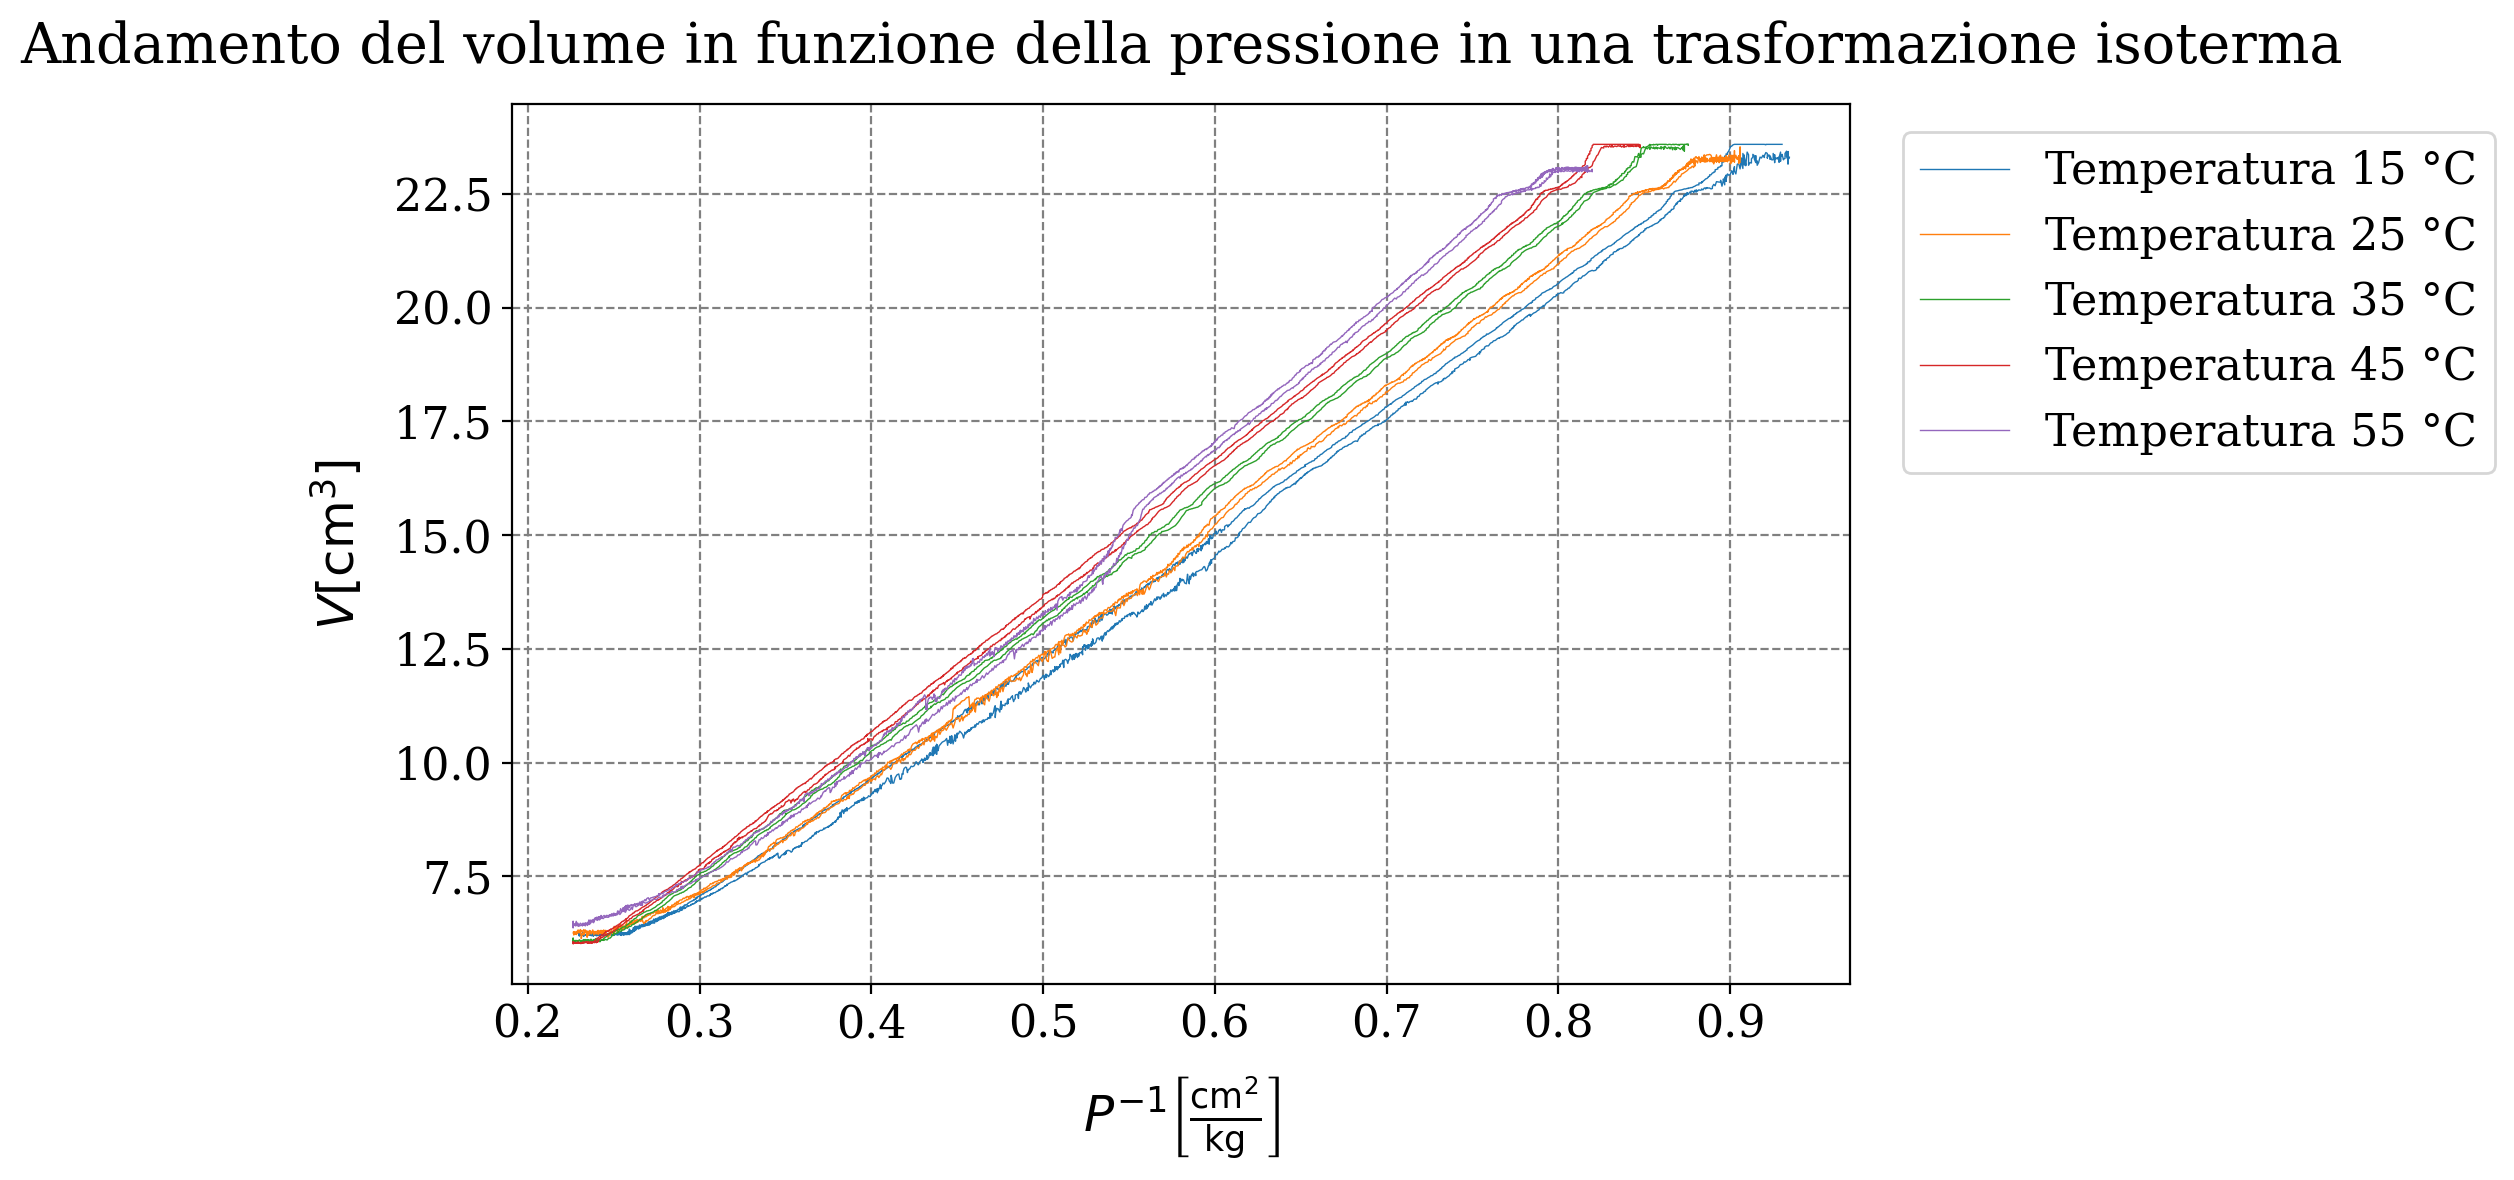

In [111]:
import itertools

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle_fisso = itertools.cycle(colors)

cmap = plt.get_cmap('Set3')
color_cycle = itertools.cycle(cmap.colors)

markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)
errori = gf.default_error_params()
gf.imposta_stile_globale()

fig, ax = plt.subplots()

for i,serie in enumerate(dati):
    color = next(color_cycle_fisso)
    temperatura = (i+1)*10 + 5
    marker = next(marker_cycle)
    label = f"Temperatura {temperatura} °C"
    ax.plot(1 / serie[0], serie[1], linewidth=0.5, label=label, color=color)

gf.parametri_grafico(ax, titolo = "Andamento del volume in funzione della pressione in una trasformazione isoterma", xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$", ylabel = r"$V [\mathrm{cm^{3}}]$")

gf.salva_grafico(fig, f"./Images/Confronto.pdf", legenda=(1,0.9))

## 2.2 Grafico residui

Opzionale: scegliere di mettere nell'ascisse i conteggi o il volume

In [112]:
asse_x_indici = True

/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]


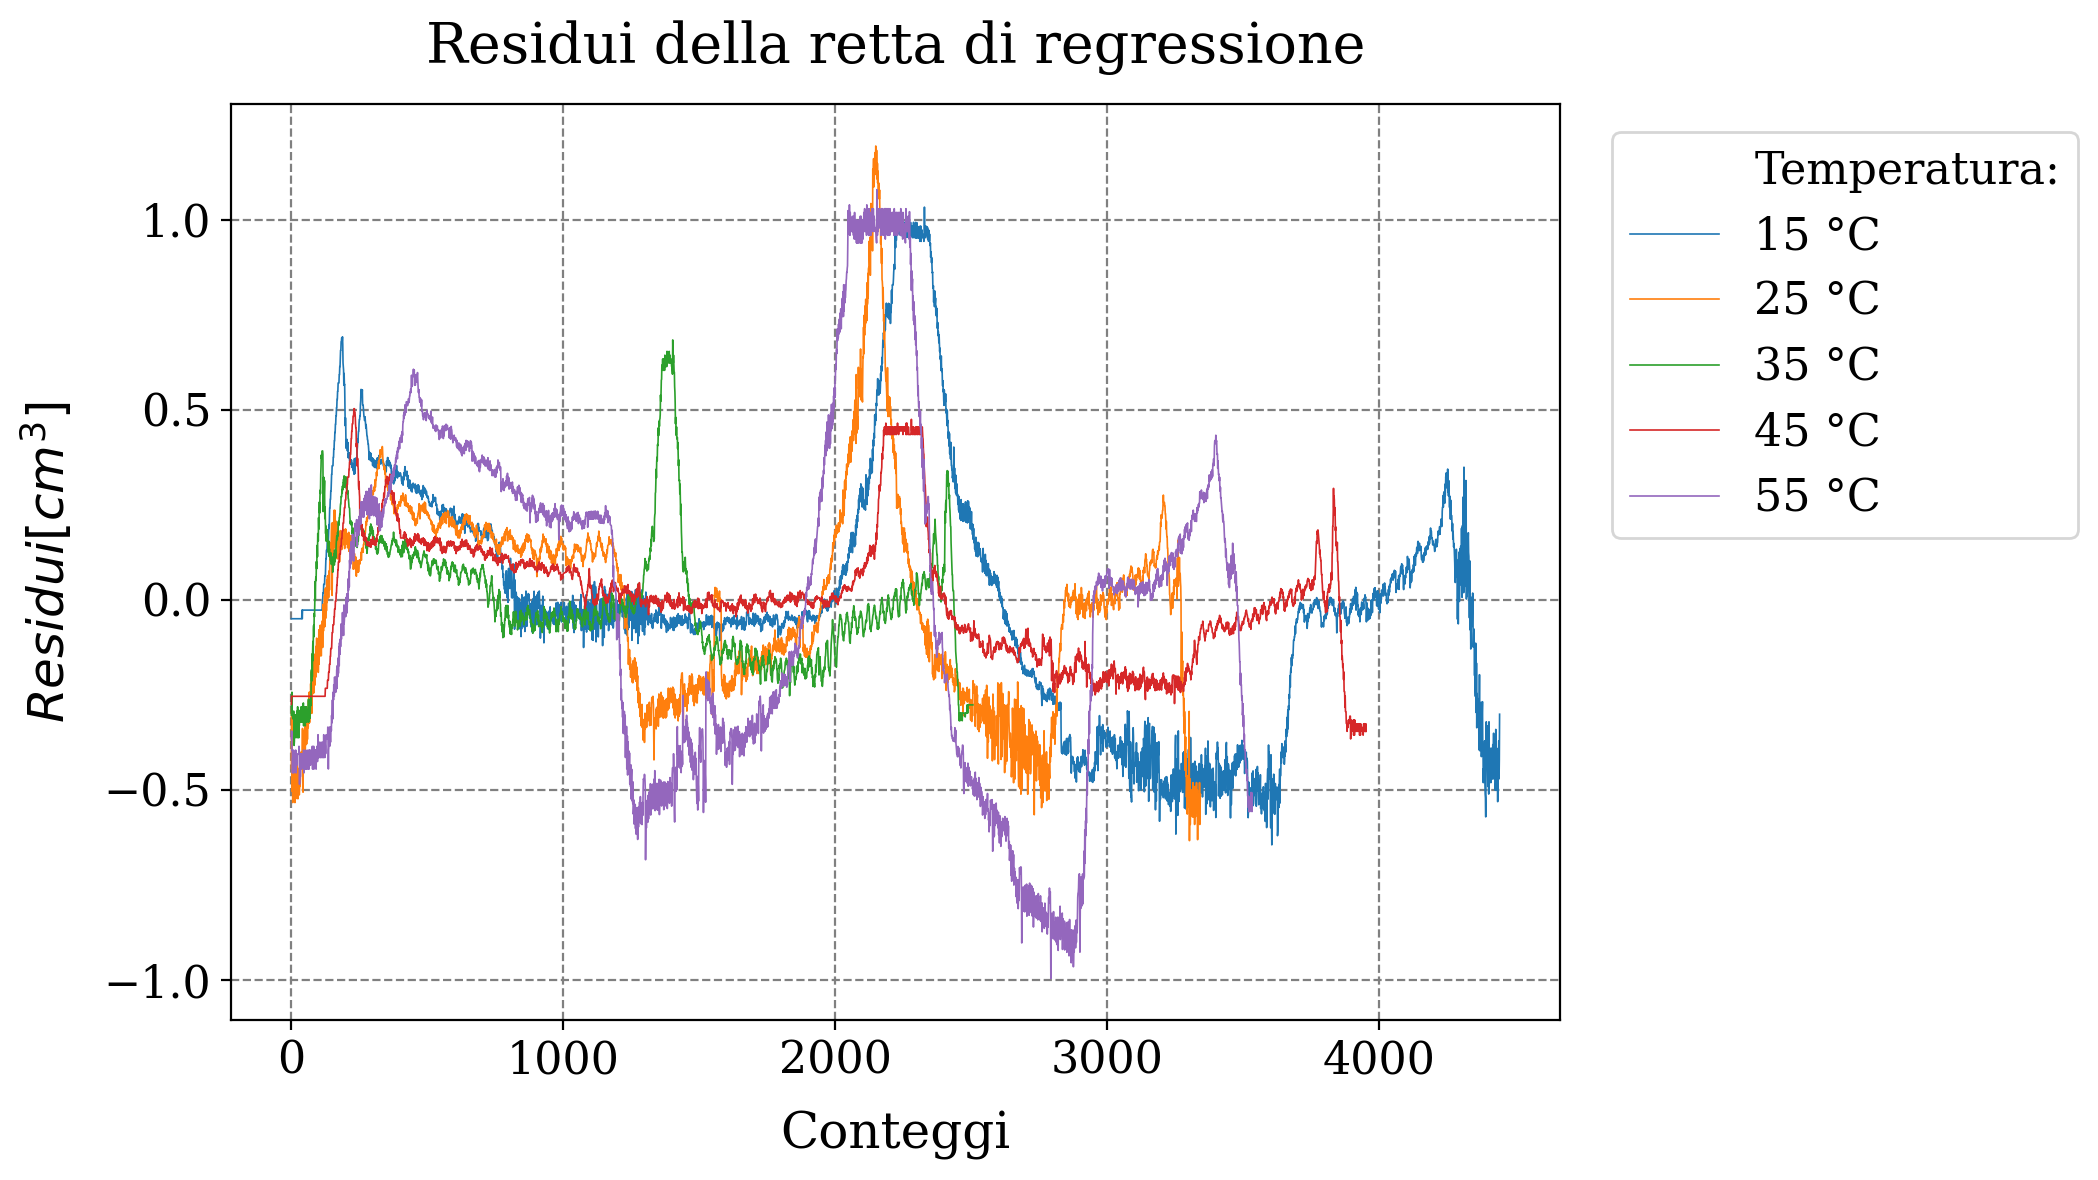

In [113]:
fig, ax = plt.subplots()
gf.descrizione_legenda(ax,"Temperatura:")

for i,serie in enumerate(dati):
    a, b, sa, sb = parametri[i]
    color = next(color_cycle_fisso)
    temperatura = (i+1)*10 + 5
    marker = next(marker_cycle)
    label = f"{temperatura} °C"

    residui=[]

    for y,x in zip(serie[1],serie[0]):
        residui.append(y - (a + b * 1/x))
    residui = np.array(residui)
    indici = list(range(0, len(residui)))
    if asse_x_indici==True: 
        ax.plot(indici, residui, linewidth=0.6, label=label, color=color)
    else: ax.plot(serie[1], residui, linewidth=0.6, label=label, color=color)
if asse_x_indici==True:
    gf.parametri_grafico(ax, titolo = "Residui della retta di regressione", xlabel = "Conteggi", ylabel = r"$Residui [cm^{3}]$")
else: gf.parametri_grafico(ax, titolo = "Residui della retta di regressione", xlabel = r"$V [cm^{3}]$", ylabel = r"$Residui [cm^{3}]$")
gf.salva_grafico(fig, f"./Images/Residui.pdf", legenda=(1,0.9))

In [114]:
def darken(color, factor=0.6):
    return tuple(factor * c for c in color)

In [115]:
asse_x_indici = False

/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]
/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]
/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]
/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  tabelle = [tabelle]
/home/nichettg/Linux Programmi/Codici/grafici.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inlin

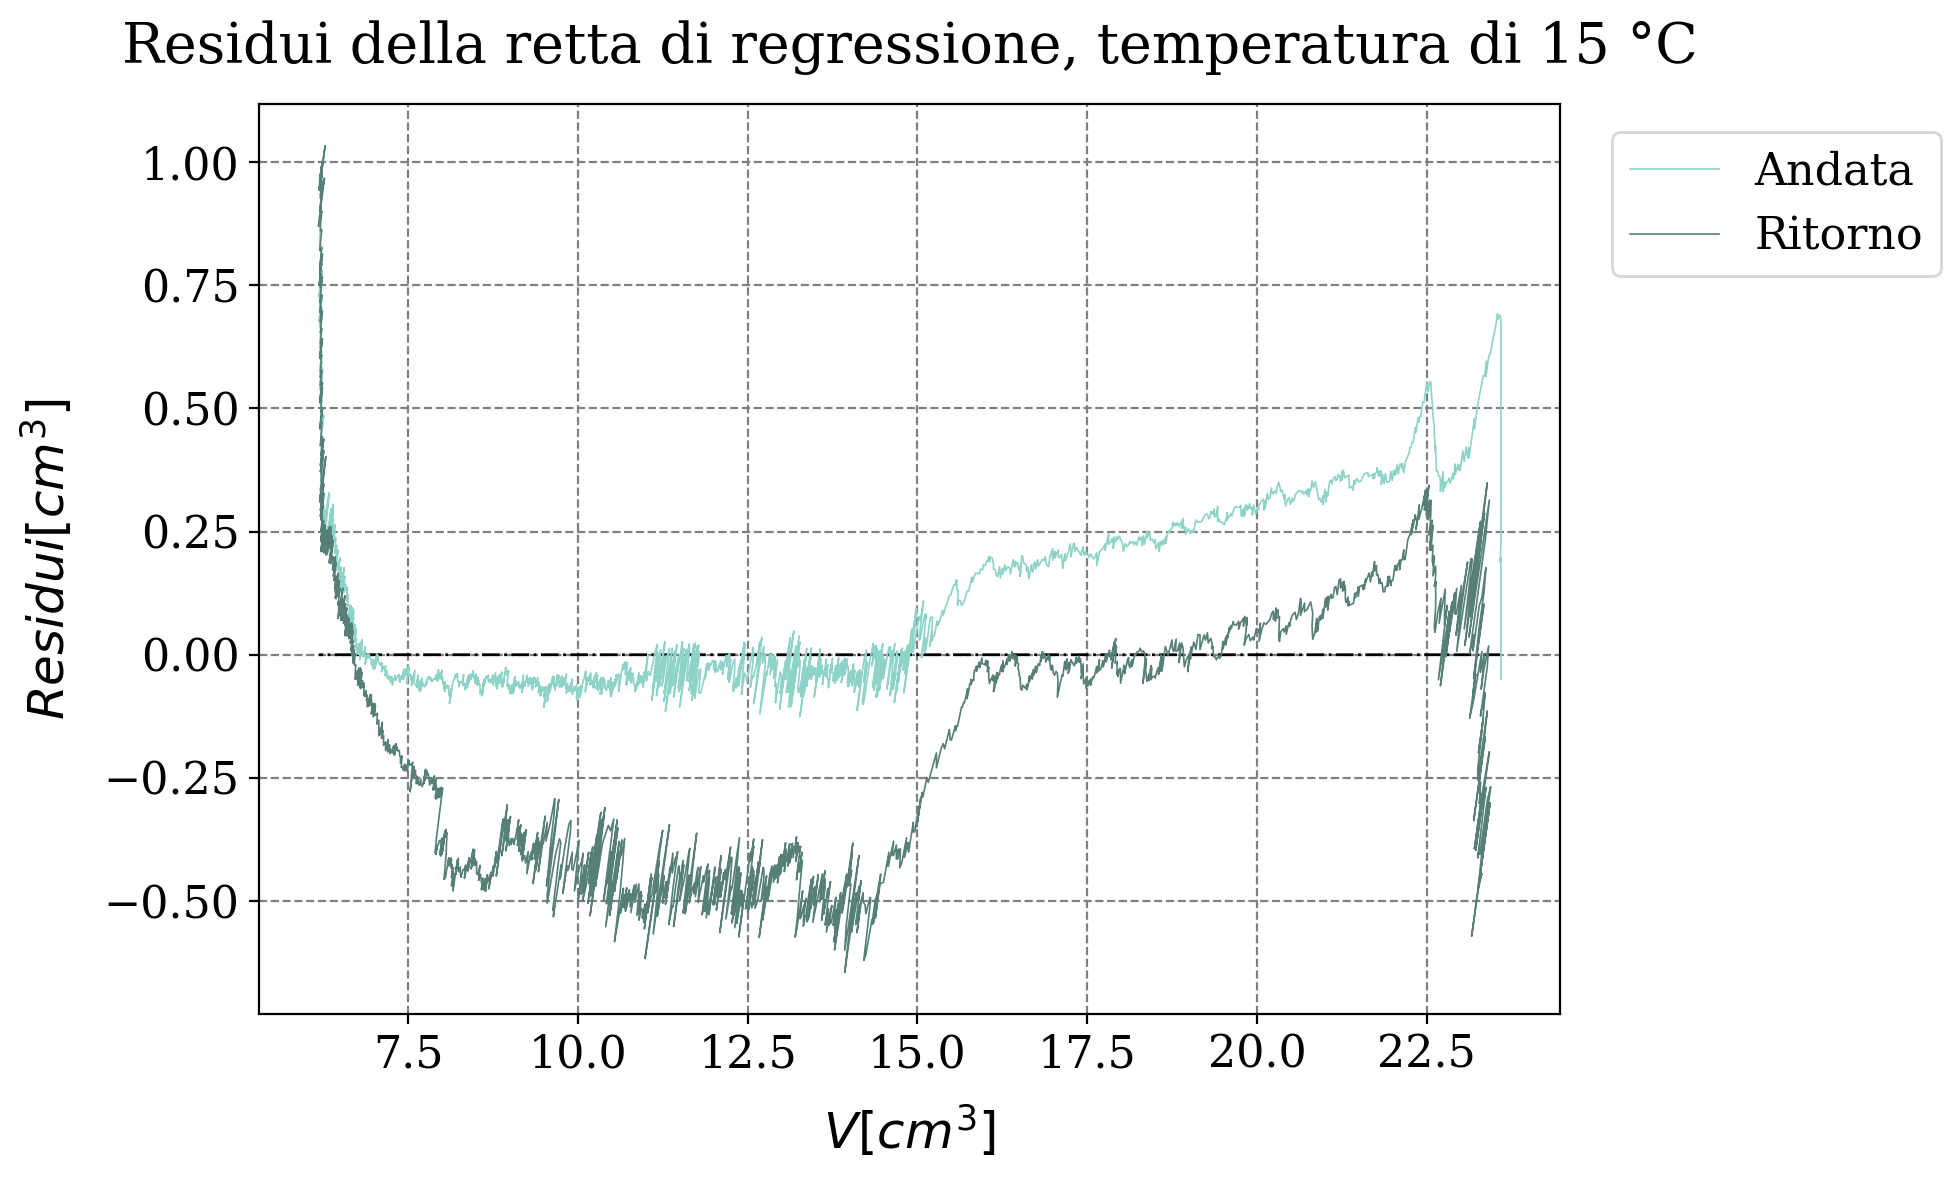

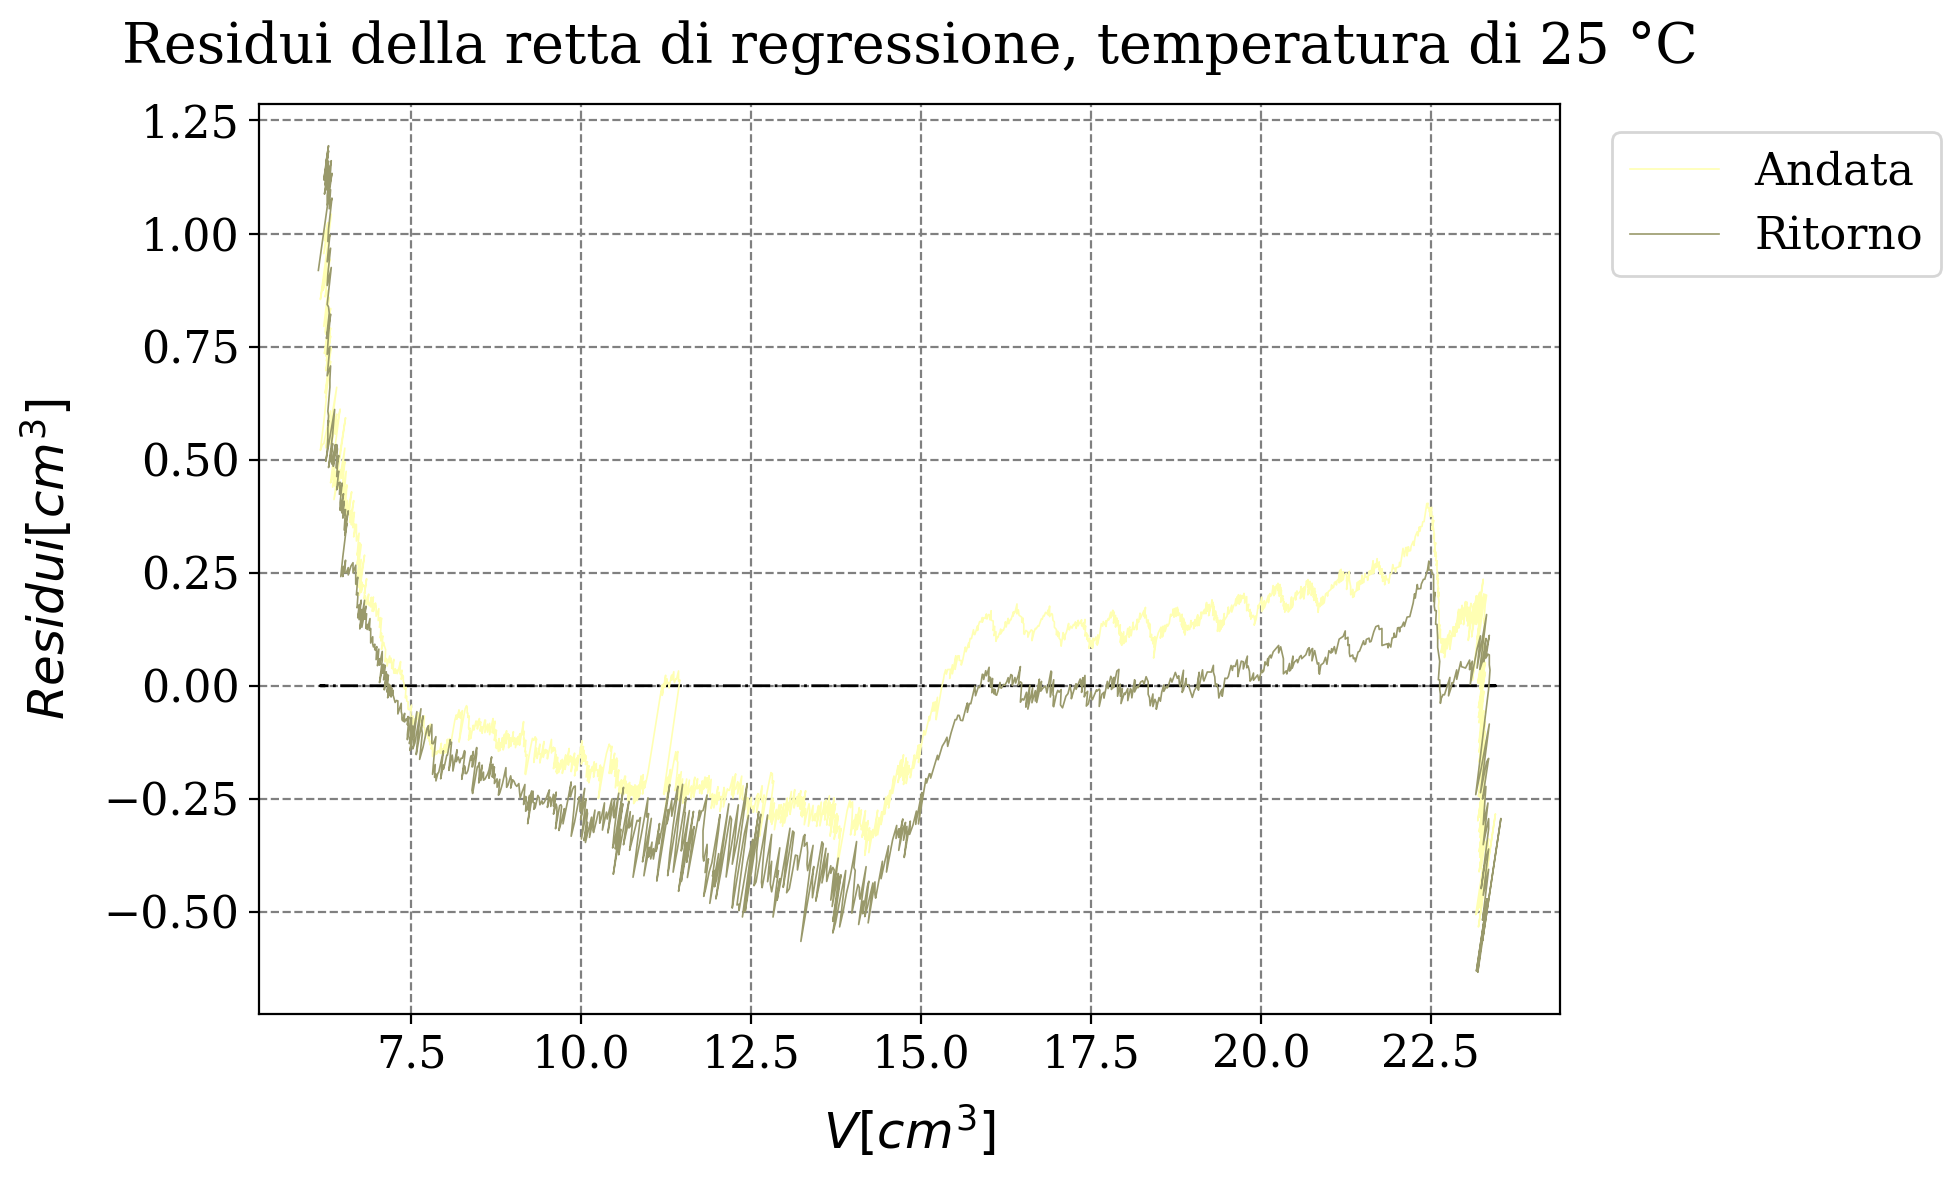

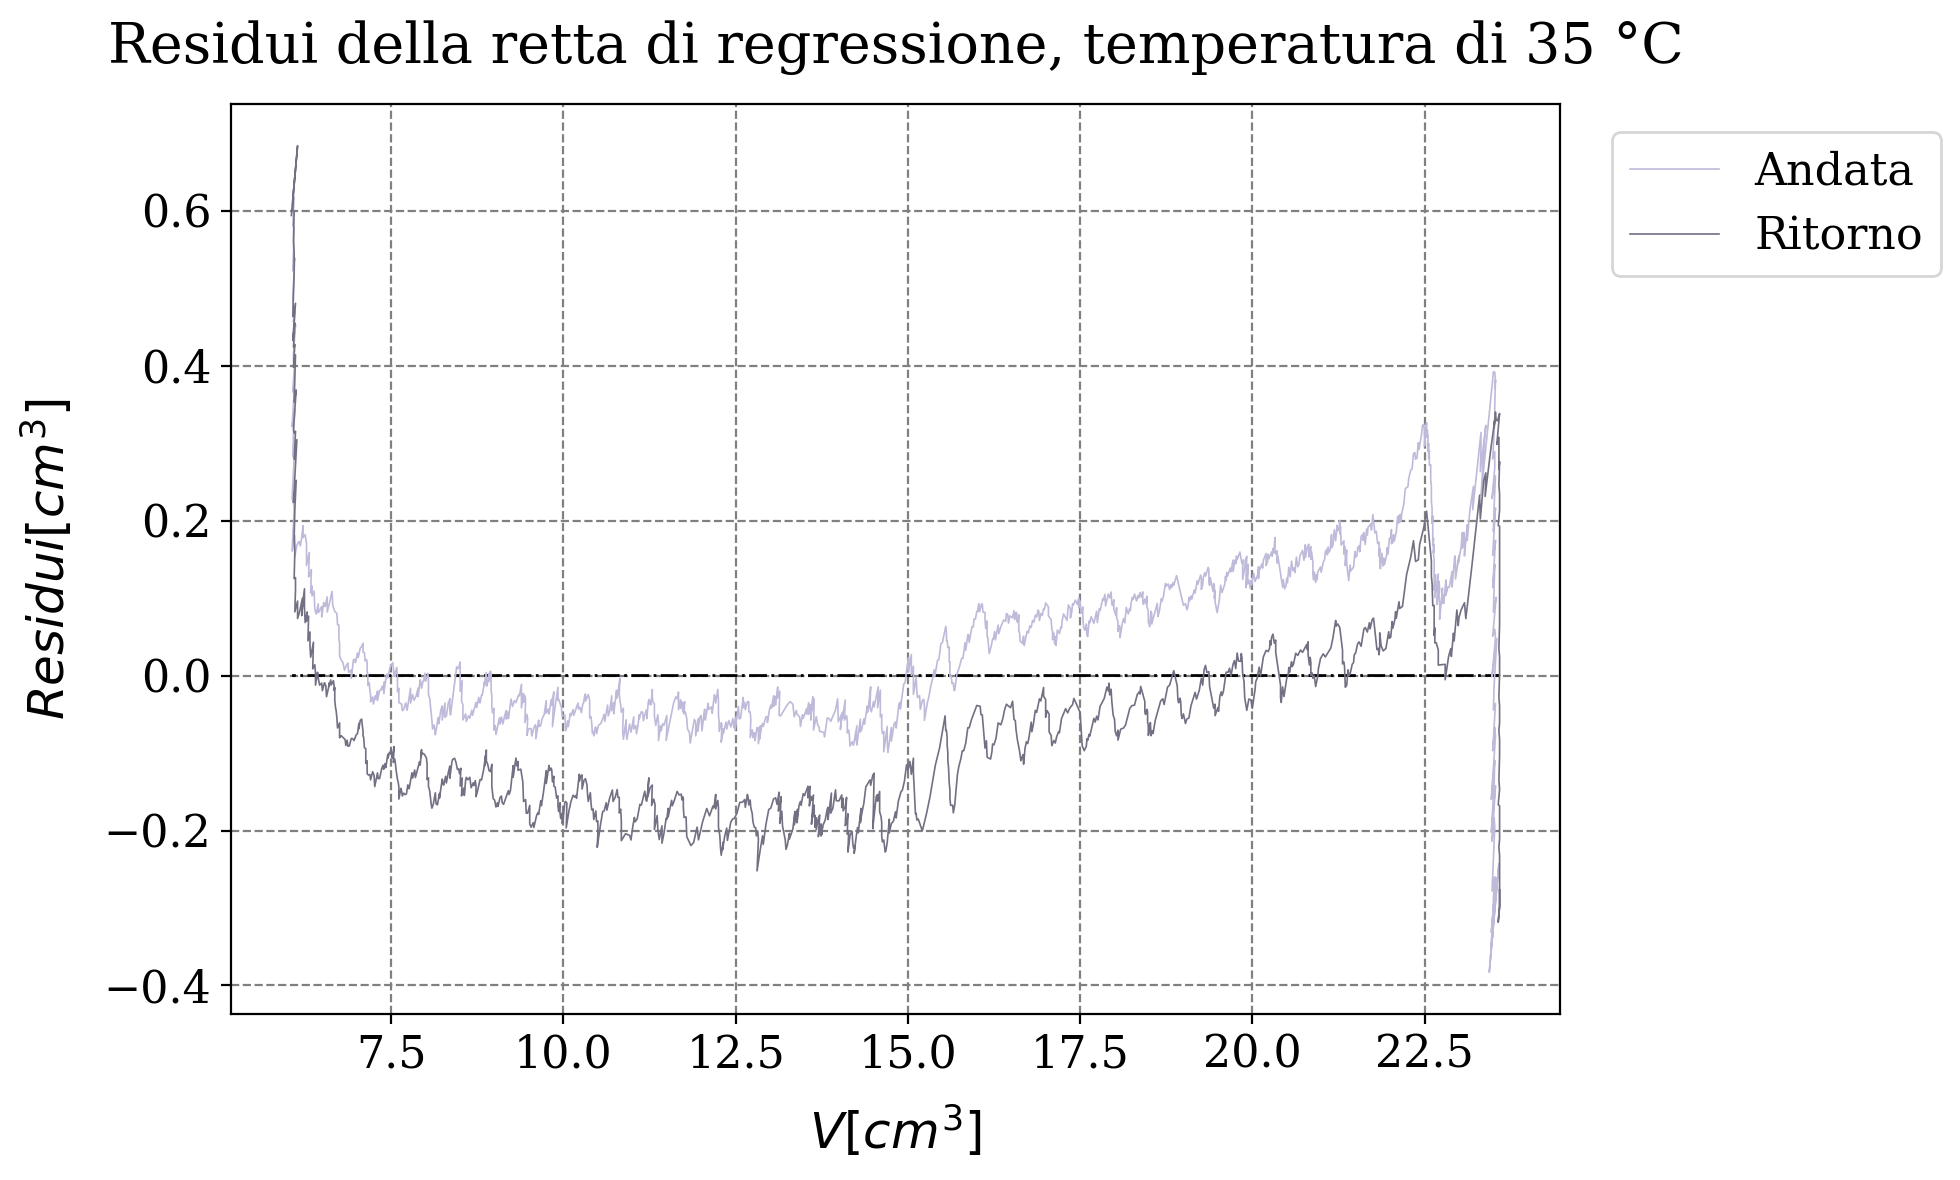

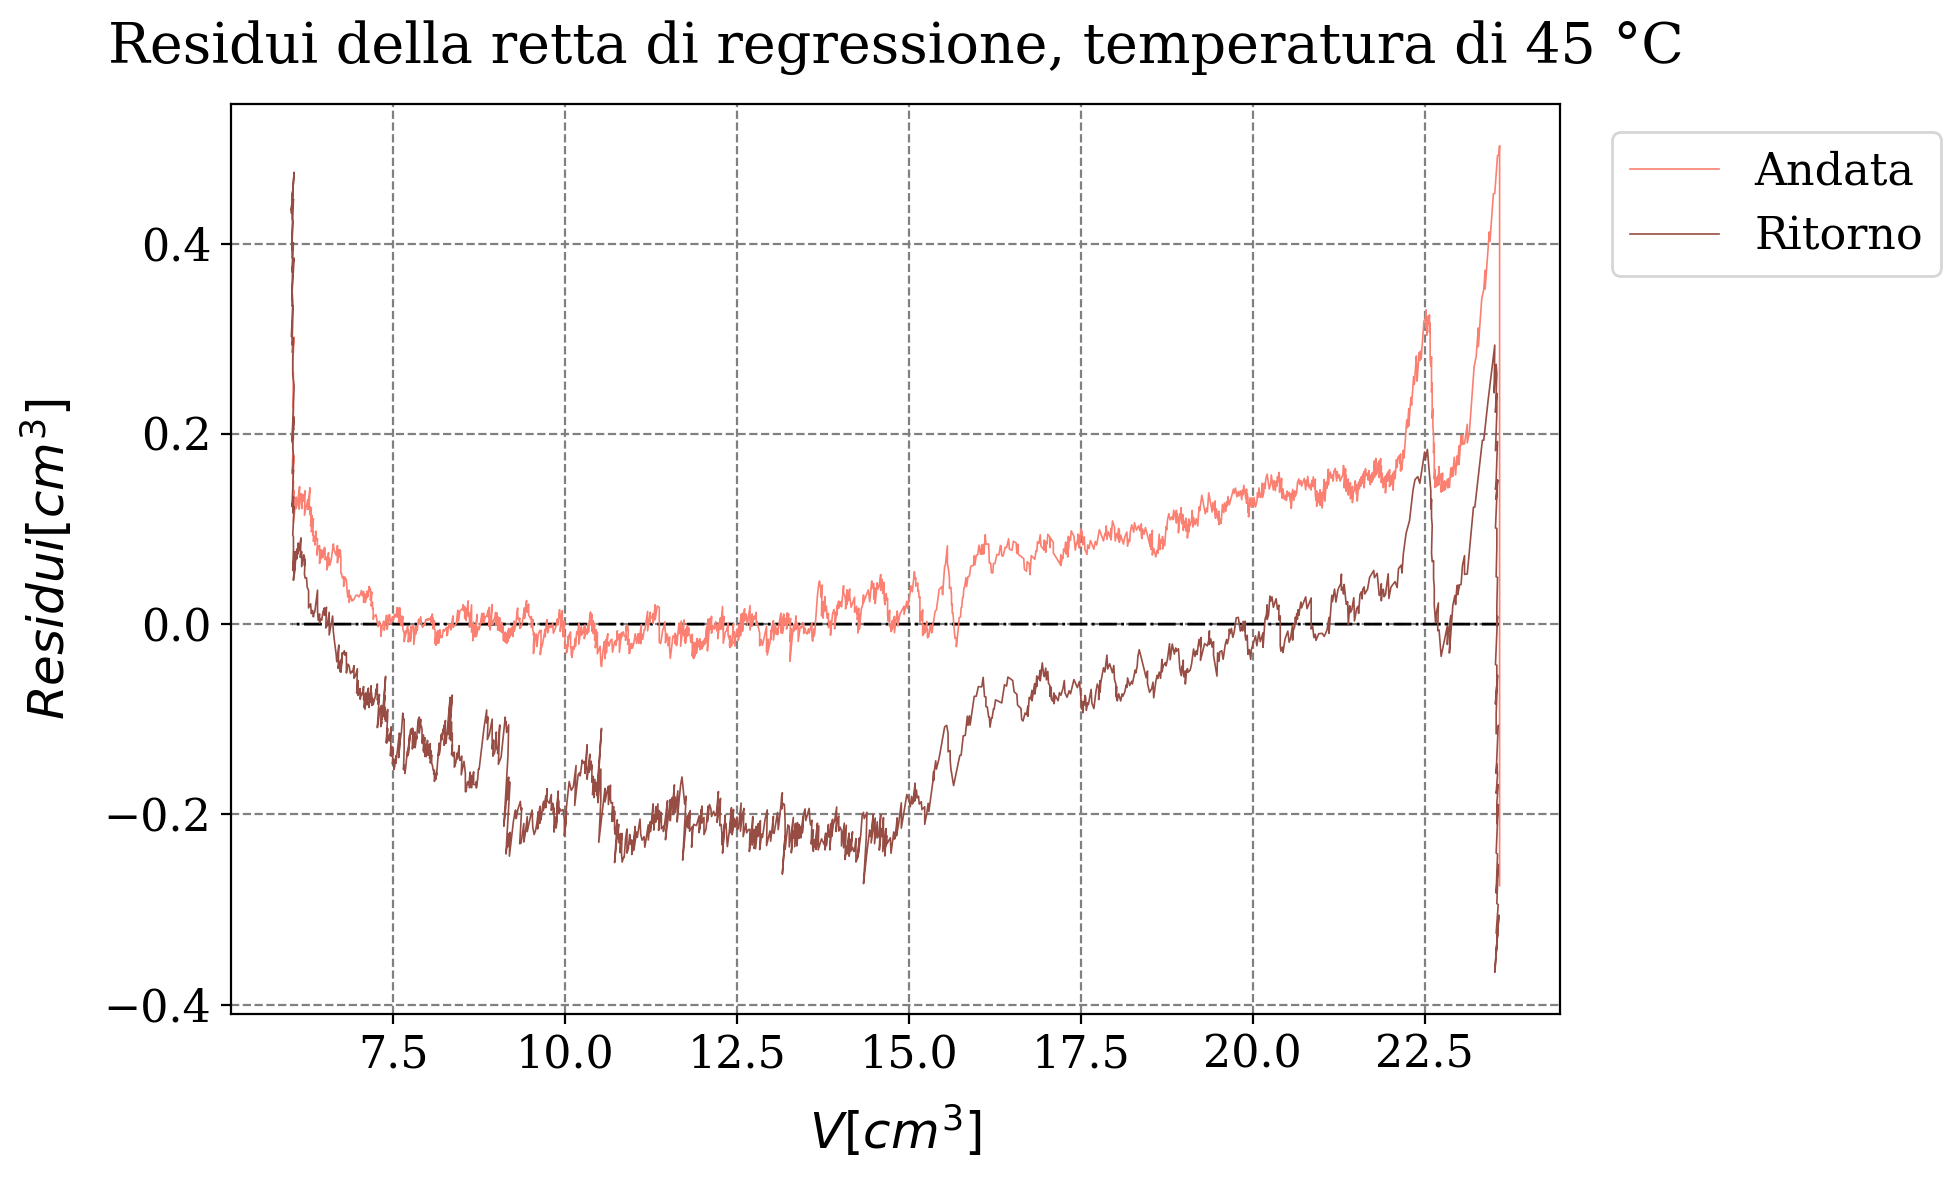

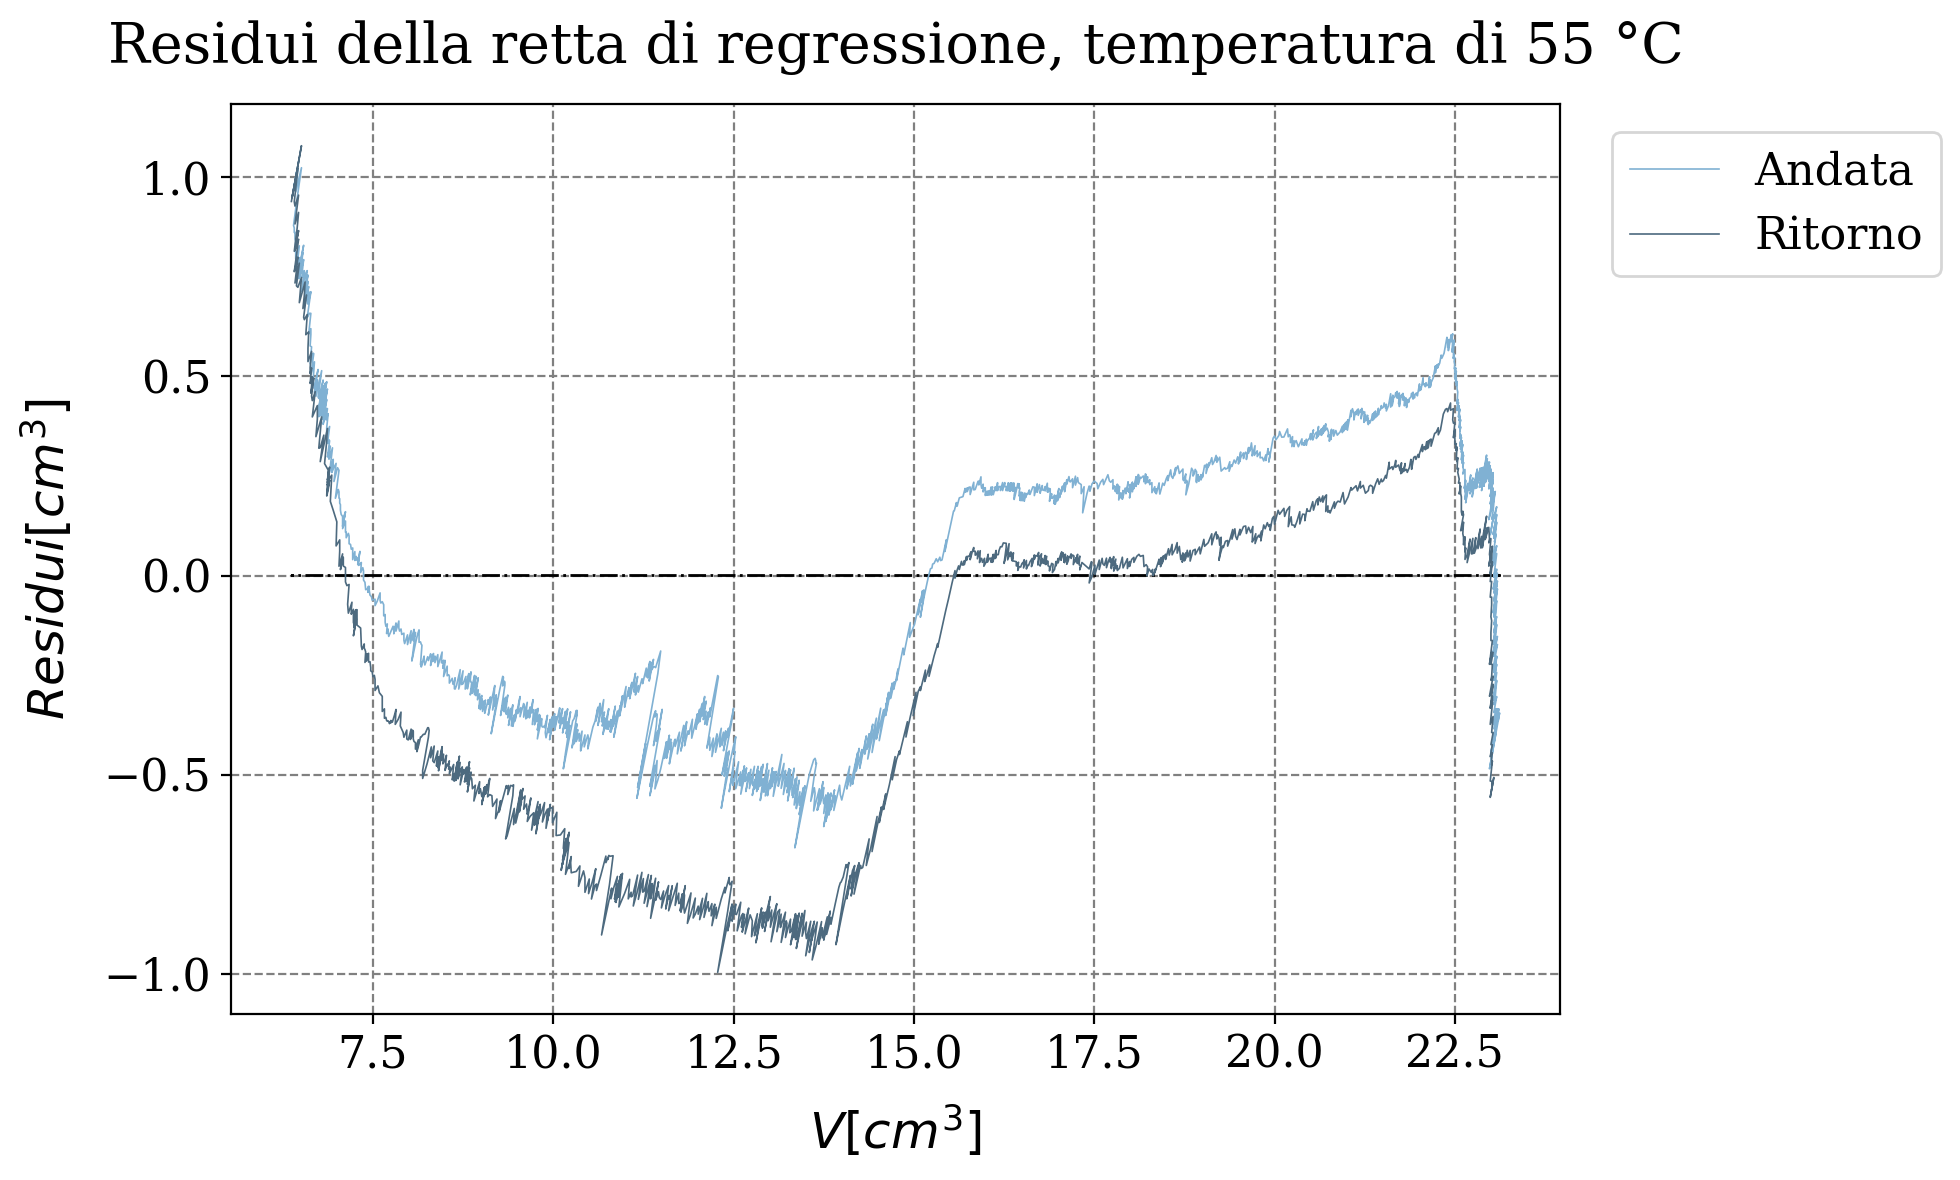

In [116]:
for i,serie in enumerate(dati):
    a, b, sa, sb = parametri[i]
    color = next(color_cycle)
    temperatura = (i+1)*10 + 5
    marker = next(marker_cycle)
    label = f"Temperatura {temperatura} °C"

    residui=[]

    for y,x in zip(serie[1],serie[0]):
        residui.append(y - (a + b * 1/x))
    residui = np.array(residui)
    indici = list(range(0, len(residui)))

    if asse_x_indici==True: ascisse = indici #indici
    else: ascisse = serie[1] #pressione

    # Splitting andata e ritorno
    residui_andata = residui[:np.argmin(serie[1])]
    residui_ritorno = residui[np.argmin(serie[1]):]
    ascisse_andata = ascisse[:np.argmin(serie[1])]
    ascisse_ritorno = ascisse[np.argmin(serie[1]):]
    
    # Creazione del grafico
    fig, ax = plt.subplots()
    gf.linea(ax, ascisse_andata)
    ax.plot(ascisse_andata, residui_andata, linewidth=0.6, label="Andata", color=color)
    ax.plot(ascisse_ritorno, residui_ritorno, linewidth=0.6, label="Ritorno", color=darken(color))
    if asse_x_indici==True:
        gf.parametri_grafico(ax, titolo = f"Residui della retta di regressione, temperatura di {temperatura} °C" , xlabel = "Conteggi", ylabel = r"$Residui [cm^{3}]$")
    else: gf.parametri_grafico(ax, titolo = f"Residui della retta di regressione, temperatura di {temperatura} °C", xlabel = r"$V [cm^{3}]$", ylabel = r"$Residui [cm^{3}]$")
    gf.salva_grafico(fig, f"./Images/Residui{i}.pdf", legenda=(1,0.9))